<a href="https://colab.research.google.com/github/Teomorales20/SenalesSistemas/blob/master/SERIE_Y_ESPECTRO_DE_FOURIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Señales de Soporte Compacto y Ortogonalidad


## Definición
Una señal \(x(t)\) se dice que tiene **soporte compacto** si es distinta de cero solamente en un intervalo finito de tiempo.  
Formalmente: existe un intervalo \([a,b]\) tal que
\[
x(t)=0, \quad \forall t \notin [a,b].
\]



## Ejemplos
1. **Pulso rectangular:**
\[
x(t) =
\begin{cases}
1, & |t|\leq T/2, \\
0, & \text{en otro caso}.
\end{cases}
\]

2. **Combinación de escalones:**
\[
x(t) = u(t+1) - u(t-2).
\]

3. **Ventanas** (Hamming, Hann, Blackman, etc.), todas tienen soporte compacto.



## Propiedades
- Energía finita: \(\int |x(t)|^2 dt < \infty\).
- Soporte compacto en tiempo \(\Rightarrow\) espectro infinito en frecuencia.
- Soporte compacto en frecuencia \(\Rightarrow\) soporte infinito en tiempo.





# Demostración: Ortogonalidad de \(\{e^{j n \lambda t}\}_{n\in \mathbb{Z}}\)

Consideremos:
\[
\varphi_n(t) = e^{j n \lambda t}, \quad n\in\mathbb{Z}, \ \lambda>0.
\]

El producto interno en un intervalo \([a,a+T]\) es:
\[
\langle \varphi_n, \varphi_m \rangle = \int_a^{a+T} e^{j(n-m)\lambda t} \, dt.
\]

---

### Caso 1: \(n=m\)
\[
\langle \varphi_n, \varphi_n \rangle = \int_a^{a+T} 1 \, dt = T.
\]

### Caso 2: \(n\neq m\)
Sea \(k=n-m\):
\[
\langle \varphi_n, \varphi_m \rangle = \frac{e^{j k \lambda (a+T)} - e^{j k \lambda a}}{j k \lambda}.
\]

Si \(\lambda T = 2\pi\), se cumple que
\[
e^{j k \lambda T} = e^{j 2\pi k} = 1,
\]
y por tanto el numerador es cero:
\[
\langle \varphi_n, \varphi_m \rangle = 0.
\]

---

### Conclusión
\[
\langle \varphi_n, \varphi_m \rangle =
\begin{cases}
T, & n=m, \\
0, & n\neq m.
\end{cases}
\]

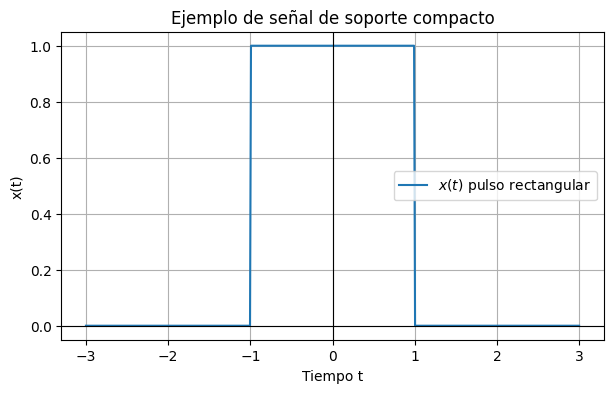

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Pulso rectangular
T = 2
t = np.linspace(-3, 3, 500)
x = np.where(np.abs(t) <= T/2, 1, 0)

plt.figure(figsize=(7,4))
plt.plot(t, x, label=r"$x(t)$ pulso rectangular")
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Ejemplo de señal de soporte compacto")
plt.xlabel("Tiempo t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

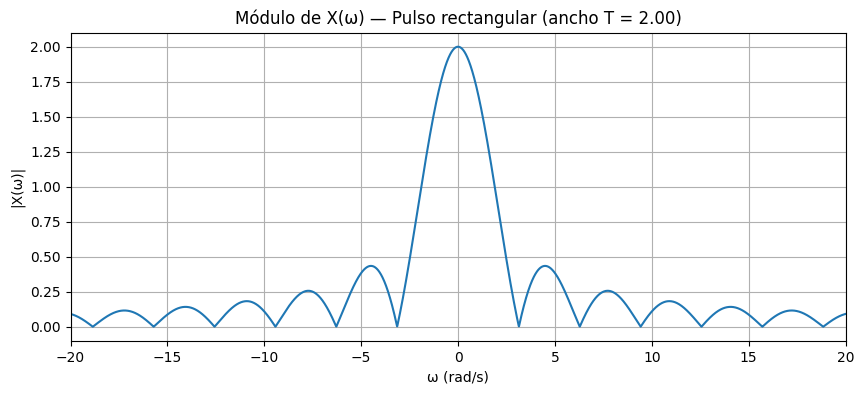

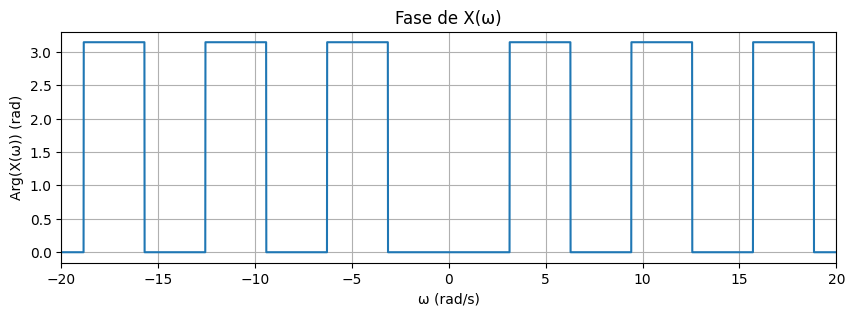

In [ ]:
# Graficar transformada de Fourier del pulso rectangular
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
T = 2.0                     # ancho del pulso
omega = np.linspace(-20, 20, 4000)   # eje de frecuencia angular (rad/s)

# Transformada analítica: X(omega) = 2*sin(omega*T/2) / omega, con límite en omega=0 => T
# Implementamos con cuidado la singularidad en omega=0
X = np.zeros_like(omega, dtype=float)
eps = 1e-12
w_nonzero = np.abs(omega) > eps
X[w_nonzero] = 2*np.sin(omega[w_nonzero]*T/2.0) / omega[w_nonzero]
X[~w_nonzero] = T  # límite cuando omega -> 0

# Módulo y fase
magnitude = np.abs(X)
phase = np.angle(X)  # devuelve fase en radianes

# Gráfica del módulo
plt.figure(figsize=(10,4))
plt.plot(omega, magnitude)
plt.title("Módulo de X(ω) — Pulso rectangular (ancho T = {:.2f})".format(T))
plt.xlabel("ω (rad/s)")
plt.ylabel("|X(ω)|")
plt.grid(True)
plt.xlim(omega[0], omega[-1])
plt.show()

# Gráfica de la fase
plt.figure(figsize=(10,3))
plt.plot(omega, phase)
plt.title("Fase de X(ω)")
plt.xlabel("ω (rad/s)")
plt.ylabel("Arg(X(ω)) (rad)")
plt.grid(True)
plt.xlim(omega[0], omega[-1])
plt.show()


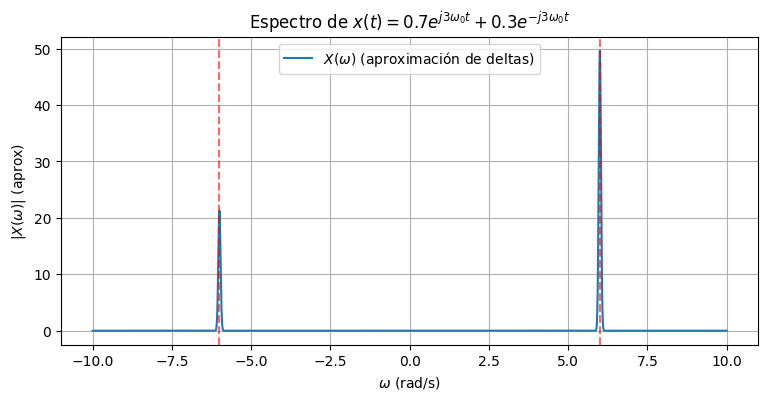

In [ ]:
# Espectro de x(t) = 0.7 e^{j3ω0 t} + 0.3 e^{-j3ω0 t}
# Representación aproximada de los deltas de Dirac

import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w0 = 2.0   # puedes cambiar el valor de ω0
w = np.linspace(-10, 10, 5000)

# Amplitudes de los deltas
A_pos = 1.4*np.pi   # en ω = +3ω0
A_neg = 0.6*np.pi   # en ω = -3ω0

# Simulamos los deltas con "gaussianas" muy angostas
def delta_approx(x, center, amp, width=0.05):
    return amp * np.exp(-((x-center)/width)**2) / (np.sqrt(np.pi)*width)

Xw = delta_approx(w,  3*w0, A_pos) + delta_approx(w, -3*w0, A_neg)

# Gráfica
plt.figure(figsize=(9,4))
plt.plot(w, Xw, label=r'$X(\omega)$ (aproximación de deltas)')
plt.axvline(3*w0, color='r', linestyle='--', alpha=0.6)
plt.axvline(-3*w0, color='r', linestyle='--', alpha=0.6)
plt.title("Espectro de $x(t)=0.7e^{j3ω_0 t}+0.3e^{-j3ω_0 t}$")
plt.xlabel(r'$\omega$ (rad/s)')
plt.ylabel(r'$|X(\omega)|$ (aprox)')
plt.grid(True)
plt.legend()
plt.show()


*# Serie de Fourier de x(t) = 0.7 e^{j3 w0 t} + 0.3 e^{-j3 w0 t}
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w0 = 2.0             # frecuencia angular fundamental (puedes cambiarla)
T = 2*np.pi / w0
t = np.linspace(-2*T, 2*T, 1000)

# Definición de x(t)
x = 0.7 * np.exp(1j*3*w0*t) + 0.3 * np.exp(-1j*3*w0*t)

# Mostrar coeficientes complejos c_n
c = {}  # diccionario de coeficientes
c[3] = 0.7
c[-3] = 0.3
print("Coeficientes no nulos (serie compleja):")
for n in sorted(c.keys()):
    print(f"c_{n} = {c[n]}")

# Mostrar forma trigonométrica
print("\nForma trigonométrica (real e imaginaria):")
print("Re{x(t)} = cos(3 w0 t)")
print("Im{x(t)} = 0.4 sin(3 w0 t)")

# Graficar parte real e imaginaria de x(t)
plt.figure(figsize=(10,4))
plt.plot(t, x.real, label='Re{x(t)}')
plt.plot(t, x.imag, label='Im{x(t)}')
plt.title('Señal x(t): parte real e imaginaria')
plt.xlabel('t')
plt.grid(True)
plt.legend()
plt.xlim(-2, 2)
plt.show()

# Graficar espectro aproximado (deltas aproximadas con gaussianas)
w = np.linspace(-10, 10, 4000)
A_pos = 1.4*np.pi  # 2π * 0.7
A_neg = 0.6*np.pi  # 2π * 0.3

def delta_approx(x, center, amp, width=0.05):
    return amp * np.exp(-((x-center)/width)**2) / (np.sqrt(np.pi)*width)

Xw = delta_approx(w, 3*w0, A_pos) + delta_approx(w, -3*w0, A_neg)

plt.figure(figsize=(10,3))
plt.plot(w, Xw)
plt.title('Aproximación del espectro X(ω) (deltas simuladas)')
plt.xlabel('ω (rad/s)')
plt.grid(True)
plt.xlim(-10,10)
plt.show()
serie de fourier*

**Serie de fourier**

Coeficientes no nulos (serie compleja):
c_-3 = 0.3
c_3 = 0.7

Forma trigonométrica (real e imaginaria):
Re{x(t)} = cos(3 w0 t)
Im{x(t)} = 0.4 sin(3 w0 t)


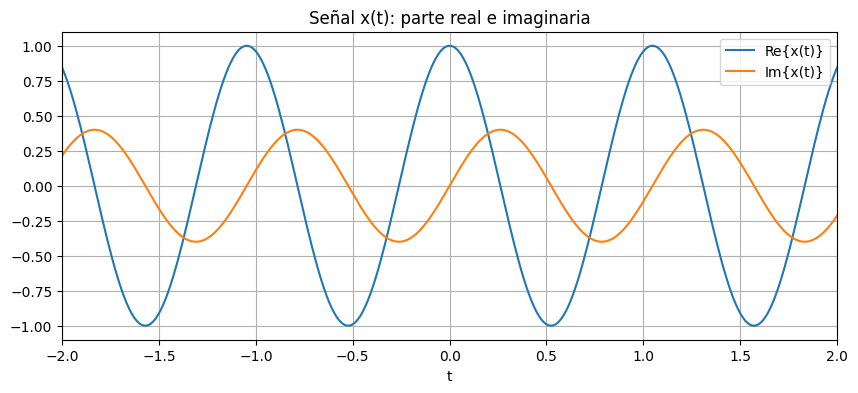

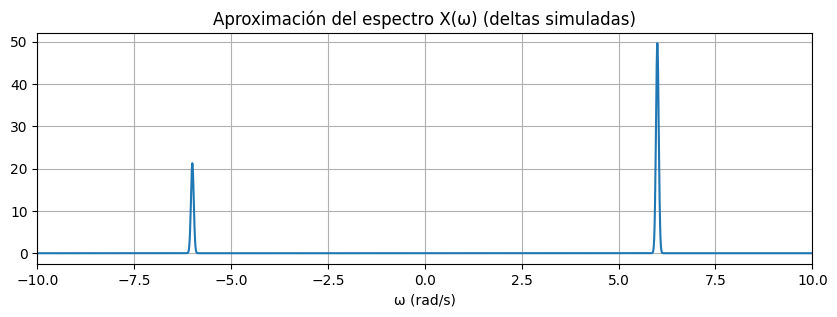

In [ ]:
# Serie de Fourier de x(t) = 0.7 e^{j3 w0 t} + 0.3 e^{-j3 w0 t}
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w0 = 2.0             # frecuencia angular fundamental (puedes cambiarla)
T = 2*np.pi / w0
t = np.linspace(-2*T, 2*T, 1000)

# Definición de x(t)
x = 0.7 * np.exp(1j*3*w0*t) + 0.3 * np.exp(-1j*3*w0*t)

# Mostrar coeficientes complejos c_n
c = {}  # diccionario de coeficientes
c[3] = 0.7
c[-3] = 0.3
print("Coeficientes no nulos (serie compleja):")
for n in sorted(c.keys()):
    print(f"c_{n} = {c[n]}")

# Mostrar forma trigonométrica
print("\nForma trigonométrica (real e imaginaria):")
print("Re{x(t)} = cos(3 w0 t)")
print("Im{x(t)} = 0.4 sin(3 w0 t)")

# Graficar parte real e imaginaria de x(t)
plt.figure(figsize=(10,4))
plt.plot(t, x.real, label='Re{x(t)}')
plt.plot(t, x.imag, label='Im{x(t)}')
plt.title('Señal x(t): parte real e imaginaria')
plt.xlabel('t')
plt.grid(True)
plt.legend()
plt.xlim(-2, 2)
plt.show()

# Graficar espectro aproximado (deltas aproximadas con gaussianas)
w = np.linspace(-10, 10, 4000)
A_pos = 1.4*np.pi  # 2π * 0.7
A_neg = 0.6*np.pi  # 2π * 0.3

def delta_approx(x, center, amp, width=0.05):
    return amp * np.exp(-((x-center)/width)**2) / (np.sqrt(np.pi)*width)

Xw = delta_approx(w, 3*w0, A_pos) + delta_approx(w, -3*w0, A_neg)

plt.figure(figsize=(10,3))
plt.plot(w, Xw)
plt.title('Aproximación del espectro X(ω) (deltas simuladas)')
plt.xlabel('ω (rad/s)')
plt.grid(True)
plt.xlim(-10,10)
plt.show()
